# Loan Approval Kaggle EDA

## Objective
Explore the Kaggle loan approval training dataset, understand its structure, inspect missing values, study target distribution, and prepare it for preprocessing and modeling.

## Dataset
`../Dataset/LoanApprovalKaggle/train_u6lujuX_CVtuZ9i.csv`


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
df = pd.read_csv("../Dataset/LoanApprovalKaggle/train_u6lujuX_CVtuZ9i.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.info()

Shape: (614, 13)

Columns:
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-nul

## Observations
- This dataset has a target column: `Loan_Status`.
- Dataset contains mixed value  numerical and categorical variables.
- Missing values are present in mostly in Loan Amount, so preprocessing and cleaning is required


In [16]:
df.describe(include="all")


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


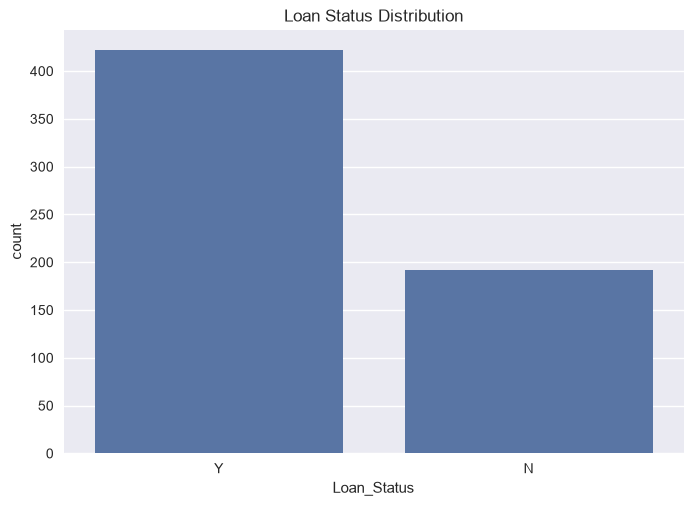

In [17]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

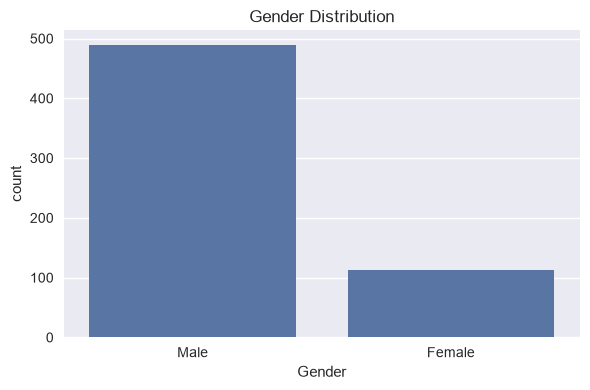

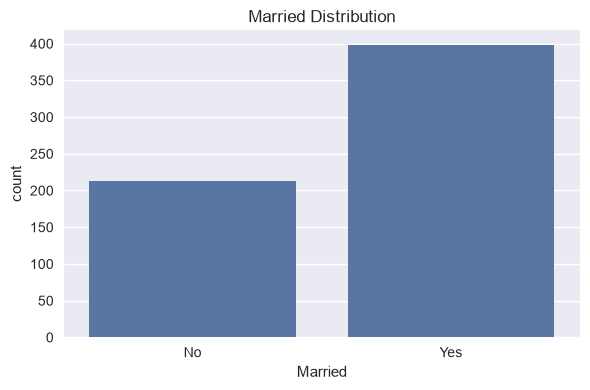

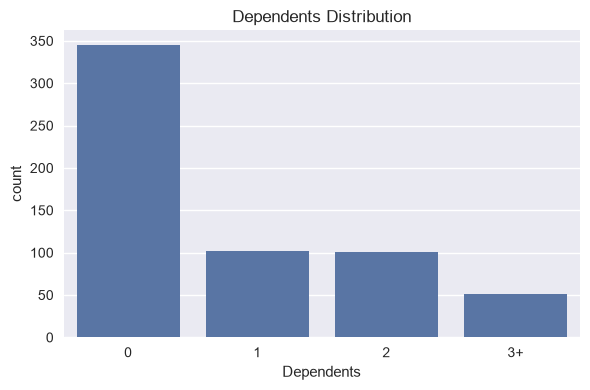

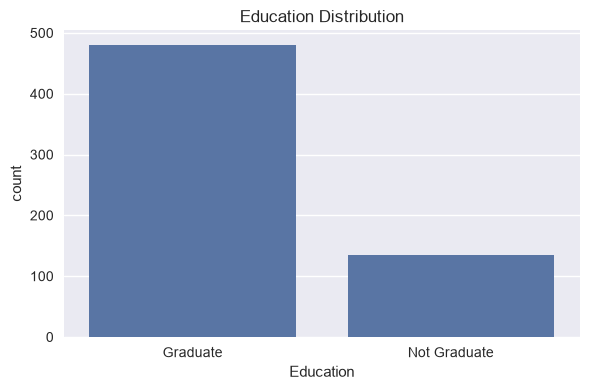

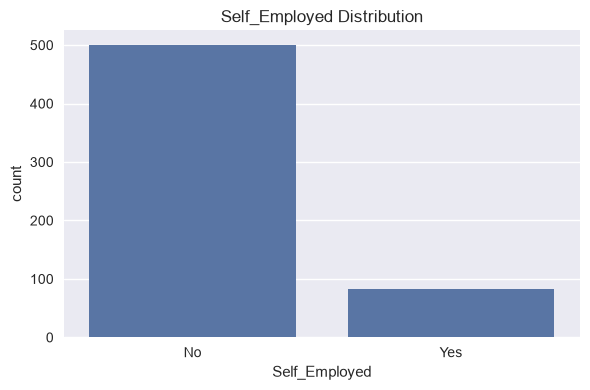

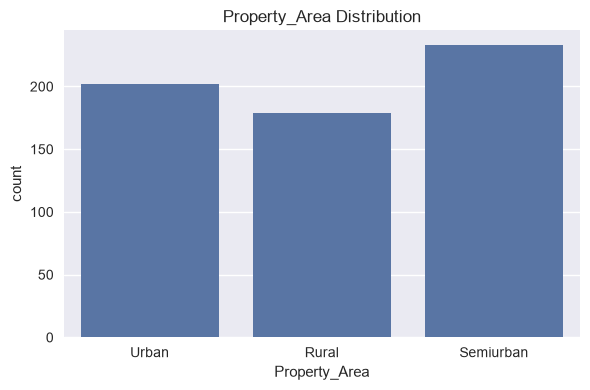

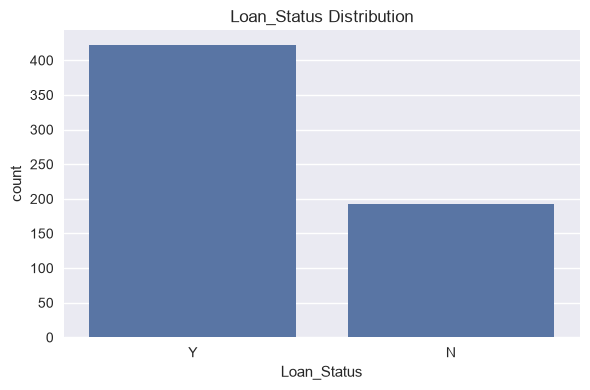

In [18]:
categorical_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area","Loan_Status"]
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks()
    plt.tight_layout()
    plt.show()

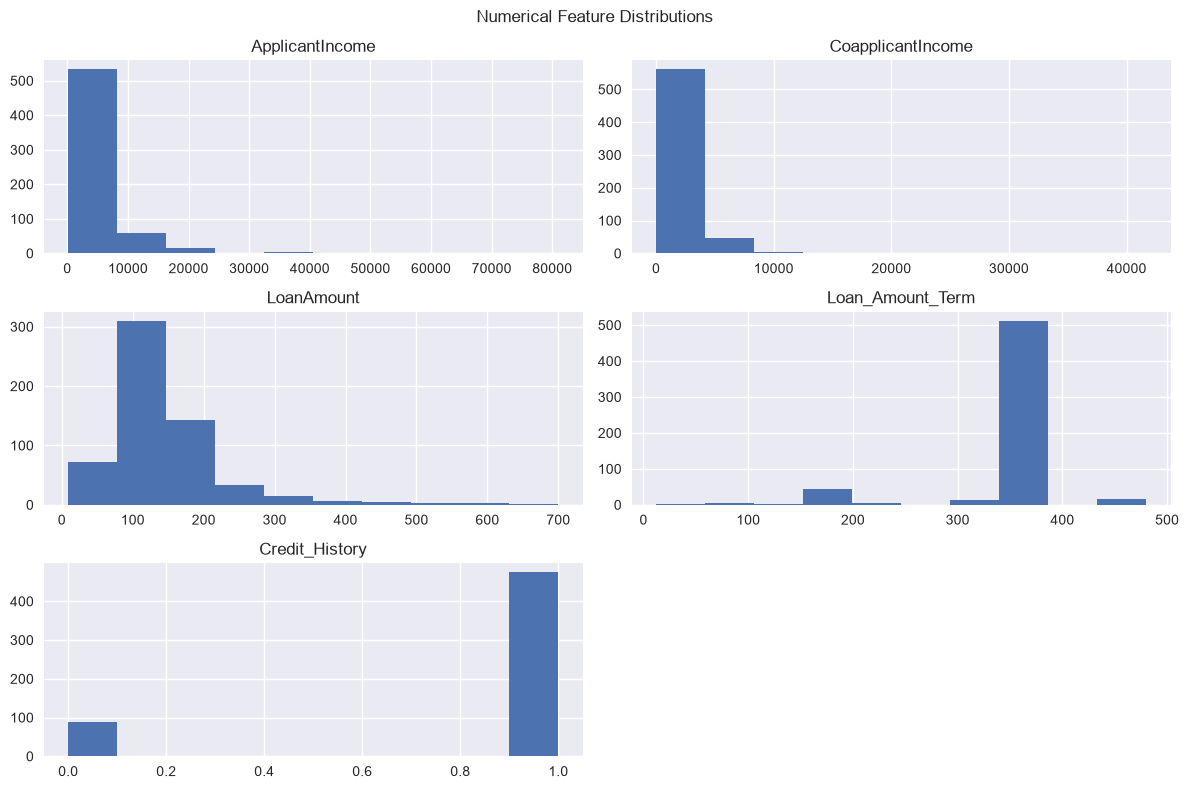

In [19]:
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

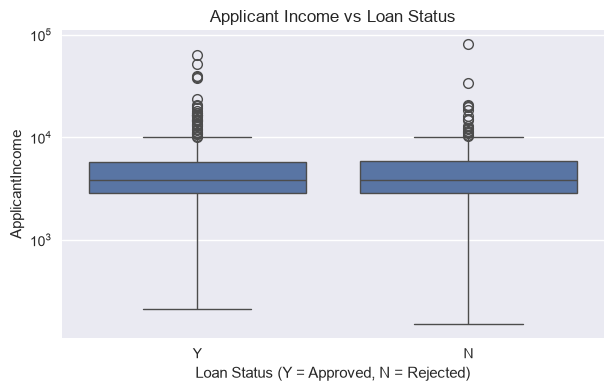

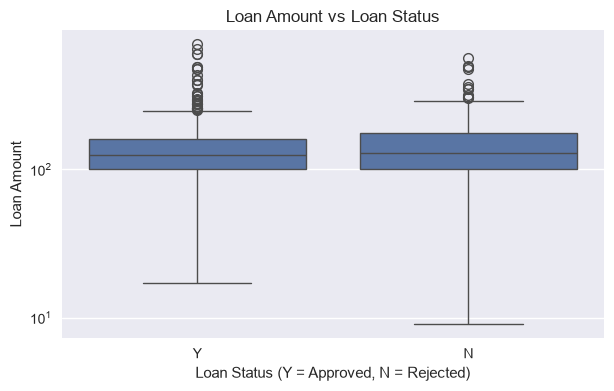

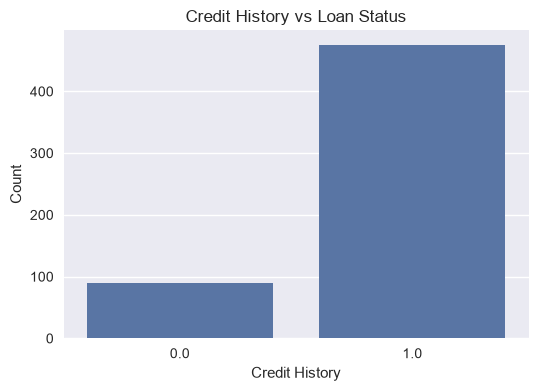

In [34]:
plot_df = df.copy()


plt.figure(figsize=(7,4))
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=plot_df)
plt.yscale("log")
plt.title("Applicant Income vs Loan Status")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(x="Loan_Status", y="LoanAmount", data=plot_df)
plt.yscale("log")
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.ylabel("Loan Amount")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Credit_History",  data=plot_df)
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.show()

## EDA Conclusion
- Loan ammount and income do not majorly effect the loan status
- `Credit_History` is expected to be an important predictor.



# Data Preprocessing

## Objective
Cleaning  the loan dataset,working on missing values, encoding features, and preparing a reusable preprocessing for model training and deployment.

## it requires
- The dataset contains missing values across multiple columns.
- The model needs consistent transformations during both training and deployment.
- The deployment app should reuse the same saved preprocessing object used during model training.


In [21]:
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == 'notebook' else Path.cwd().resolve()
ARTIFACTS_DIR = ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

final_df = pd.read_csv(ROOT / 'Dataset' / 'LoanApprovalKaggle' / 'train_u6lujuX_CVtuZ9i.csv')
final_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [22]:
print('Missing values before preprocessing:')
print(final_df.isnull().sum())

print('\nDuplicate rows:', final_df.duplicated().sum())

final_df = final_df.drop_duplicates().copy()
final_df['Dependents'] = final_df['Dependents'].replace('3+', '3')
final_df['Loan_Status'] = final_df['Loan_Status'].map({'Y': 1, 'N': 0})
final_df.head()

Missing values before preprocessing:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate rows: 0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


## Preprocessing Design
- `Loan_ID` is removed because it is only an identifier.
- Numerical columns use median for  scaling.
- Categorical columns use most-frequent  and one-hot encoding.


In [36]:
X = final_df.drop(columns=['Loan_Status', 'Loan_ID'])
y = final_df['Loan_Status']

categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Training features shape after preprocessing:', X_train_processed.shape)
print('Testing features shape after preprocessing:', X_test_processed.shape)

Training features shape after preprocessing: (491, 20)
Testing features shape after preprocessing: (123, 20)


# Model Training

This below block trains three classifiers model for the selected Kaggle dataset and compares them using standard classification metrics.


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    fitted_models[name] = model
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds)
    })
    print(f'\n{name} Classification Report\n')
    print(classification_report(y_test, preds))

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df


Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Decision Tree Classification Report

              precision    recall  f1-score   support

           0       0.61      0.61      0.61        38
           1       0.82      0.82      0.82        85

    accuracy                           0.76       123
   macro avg       0.71      0.71      0.71       123
weighted avg       0.76      0.76      0.76       123


Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
2,Random Forest,0.821138,0.846154,0.905882,0.875000
1,Decision Tree,0.756098,0.823529,0.823529,0.823529


In [43]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print('Best model:', best_model_name)
print(results_df.iloc[0])

Best model: Logistic Regression
Model        Logistic Regression
Accuracy                0.861789
Precision                   0.84
Recall                  0.988235
F1 Score                0.908108
Name: 0, dtype: object


# Save Deployment Artifacts

This step saves the final preprocessing object and selected model in the deployment layout expected by `application.py`.


In [26]:
import joblib

joblib.dump(preprocessor, ARTIFACTS_DIR / 'preprocessor.pkl')
joblib.dump(best_model, ARTIFACTS_DIR / 'model.pkl')

print('Saved:', ARTIFACTS_DIR / 'preprocessor.pkl')
print('Saved:', ARTIFACTS_DIR / 'model.pkl')

Saved: C:\Users\varun\private\project\Loan_Pridiction\artifacts\preprocessor.pkl
Saved: C:\Users\varun\private\project\Loan_Pridiction\artifacts\model.pkl


## Preprocessing and Training Conclusion
- The selected Kaggle dataset is now prepared for end-to-end modeling.
- The preprocessing pipeline is reusable for both evaluation and deployment.
- After running the notebook successfully, the Flask deployment app can use `artifacts/model.pkl` and `artifacts/preprocessor.pkl` directly.
